## Abstract

This report examines weekly SPY log returns from 2000 to 2019 to assess
whether the data support a regime-switching description of volatility.
Annualised rolling volatility ranges from roughly 10% to 54%, excess
kurtosis is 9.48, and while raw returns show no significant
autocorrelation, absolute and squared returns remain persistent for many
weeks. The variance is therefore time-varying and persistent while the mean
is not, pointing to a two-state model with a common mean and switching
variance; whether such regimes can be detected in real time is left to the
remainder of the project.

## 1. Purpose

The purpose of this study is to examine and ascertain whether the returns of the SPY ETF exhibit the statistical properties required to justify the application of a regime-switching model.

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
from scipy import  stats
from statsmodels.graphics.tsaplots import plot_acf


## 2. Data
| | |
|---|---|
| Source | Yahoo Finance, via `yfinance` |
| Instrument | SPDR S&P 500 ETF Trust (SPY), dividend- and split-adjusted |
| Period | 2000-01-01 – 2019-12-31 |
| Frequency | Weekly, last close of each week ending Friday (`W-FRI`) |

SPY tracks the S&P 500 and serves here as a proxy for the broad U.S. equity market. Prices are adjusted so that ex-dividend dates are not recorded as losses.

The 2000 start date gives the sample two independent crisis episodes: the dot-com decline of 2000-2002 and the global financial crisis of 2007-2009. With only one, the high-variance state would be identified from a single event. Data from 2020 onward is reserved as an out-of-sample test set.


## 3. Methodology
This methodology section outlines the primary mathematical frameworks and techniques employed in this study.

### Log returns
$$ r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right) $$

Log returns are additive across periods: a multi-week return is a sum rather
than a product. They are also unbounded below, whereas simple returns cannot
fall below −1. The Gaussian is therefore a coherent null model for log
returns — a null this report proceeds to test.

### Rolling volatility
Volatility is measured as the standard deviation of returns over a trailing
26-week window,

$$ \hat{\sigma}_t = \sqrt{\frac{1}{25}\sum_{i=0}^{25}\left(r_{t-i}-\bar{r}_t\right)^2} $$

and annualised by $\sqrt{52}$, which assumes returns are uncorrelated across
weeks. The window length trades responsiveness against estimation noise:
shorter windows react faster but are unstable, longer windows smooth over
short episodes. Section 6 revisits this choice.

### Excess kurtosis
$$ \text{Kurt}_{\text{excess}} = \frac{\mathbb{E}\left[(r-\mu)^4\right]}{\sigma^4} - 3 $$

The subtraction sets the Gaussian reference to zero; positive values indicate
heavier tails. Estimates use the bias-adjusted sample estimator implemented in
`pandas.Series.kurtosis`.

### Autocorrelation
$$ \rho_k = \frac{\operatorname{Cov}(r_t,\, r_{t-k})}{\operatorname{Var}(r_t)} $$

The Autocorrelation Function (ACF) quantifies the historical memory of a
time series. The ACF of raw returns captures both the direction and the
magnitude of price fluctuations. Little or no autocorrelation in raw returns
indicates an absence of *linear* dependence, which is not the same as
independence.

Absolute and squared returns are used as proxies for volatility because they
isolate the magnitude of price movements from their direction. Comparing
their autocorrelation with that of raw returns therefore separates memory in
the direction of returns from memory in their magnitude.


In [2]:
#| include: false
data = yf.download("SPY", start = "2000-01-01", end  ="2019-12-31",auto_adjust=True)
save_path = "spy_data_2000_2019.csv"
data.to_csv(save_path)
spy_data = pd.read_csv("../data/spy_data_2000_2019.csv")

[*********************100%***********************]  1 of 1 completed


In [3]:
#| include: false
data_week = yf.download("SPY", start = "2000-01-01", end = "2019-12-31", auto_adjust = True, interval = "1wk")
save_path_week = "spy_data_2000-2019_1w.csv"
data_week.to_csv(save_path_week)

[*********************100%***********************]  1 of 1 completed


In [4]:
spy_weekly_data = pd.read_csv(
    "../data/spy_data_2000-2019_1w.csv", 
    skiprows=3,  
    names=["Date", "Close", "High", "Low", "Open", "Volume"], 
    parse_dates=["Date"], 
    index_col="Date"
)
spy_weekly_data["Log_Return"] = np.log(spy_weekly_data["Close"] / spy_weekly_data["Close"].shift(1))
spy_weekly_data = spy_weekly_data


## 4. Results
### 4.1 Price and Returns
These two charts illustrate the price and log returns. The clustering of fluctuations during specific time intervals on the log return plot should draw attention. There is a strong connection between these underlying drivers and regime switches.

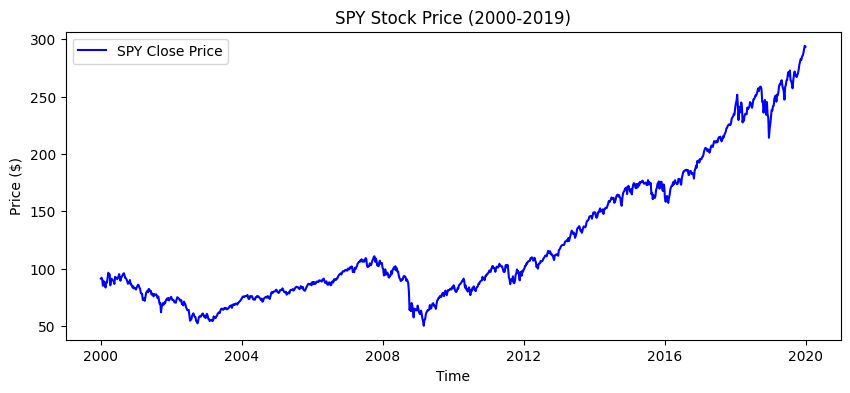

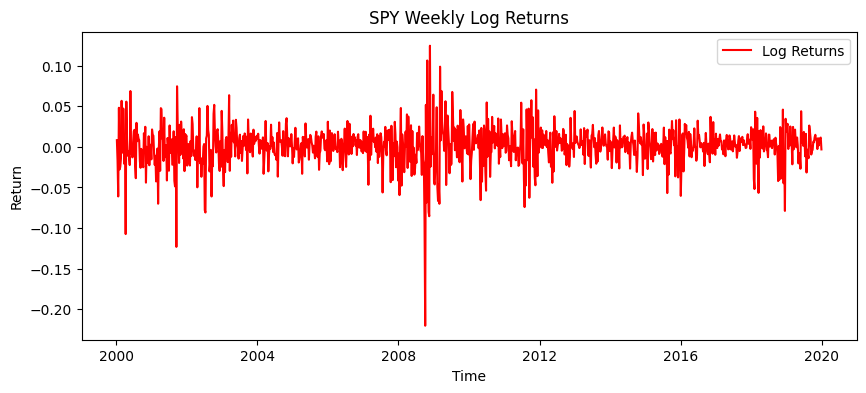

In [5]:
#| label: fig-series
#| fig-cap: "SPY weekly price and log returns, 2000-2019."
#| fig-subcap:
#|   - "Weekly closing price."
#|   - "Weekly log returns."
#| layout-ncol: 1
plt.figure(figsize=(10, 4)) 
plt.plot(spy_weekly_data.index, spy_weekly_data["Close"], label="SPY Close Price", color="blue")
plt.title("SPY Stock Price (2000-2019)")
plt.xlabel("Time")
plt.ylabel("Price ($)")
plt.legend()
plt.show() 

plt.figure(figsize=(10, 4)) 
plt.plot(spy_weekly_data.index, spy_weekly_data["Log_Return"], color="red", label="Log Returns")
plt.title("SPY Weekly Log Returns")
plt.xlabel("Time")
plt.ylabel("Return")
plt.legend()
plt.show() 

### 4.2 Rolling Volatility

For each observation, the weekly variance is estimated using a 26-week rolling window that includes the current observation and the preceding 25 weekly returns. Each weekly standard deviation is then multiplied by $\sqrt{52}$ to calculate the annualized volatility. Volatility clustering is clearly visible in the plot. 

In [6]:
window_size = 26

spy_weekly_data["Rolling_Weekly_Volatility"] = spy_weekly_data["Log_Return"].rolling(window = window_size).std()
spy_weekly_data["Annual_Rolling_Volatility"] = spy_weekly_data["Rolling_Weekly_Volatility"] * np.sqrt(52)
max_vol = spy_weekly_data["Annual_Rolling_Volatility"].max()
max_vol_date = spy_weekly_data["Annual_Rolling_Volatility"].idxmax()
print(f"Maximum annual volatility: {max_vol:.1%} on {max_vol_date:%Y-%m-%d}")



Maximum annual volatility: 54.1% on 2009-03-21


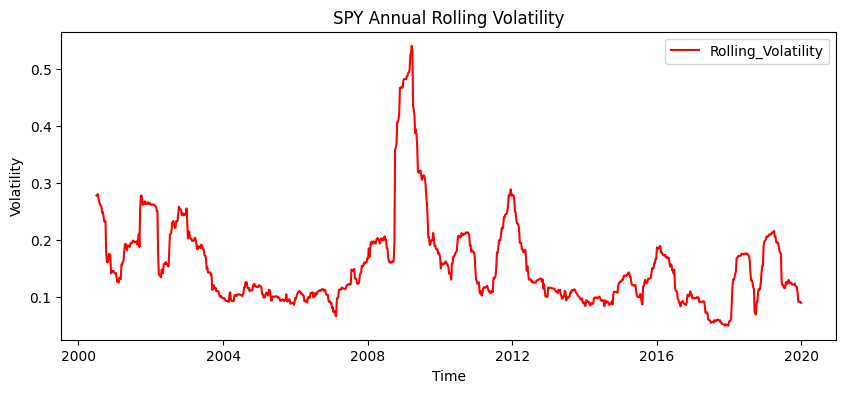

In [7]:
#| label: fig-vol
#| fig-cap: "Annualised volatility over a trailing 26-week window."
plt.figure(figsize=(10, 4)) 
plt.plot(spy_weekly_data.index, spy_weekly_data["Annual_Rolling_Volatility"], color="red", label="Rolling_Volatility")
plt.title("SPY Annual Rolling Volatility")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.legend()
plt.show() 

### 4.3 Return distribution and tail behaviour
In financial modeling, asset returns are often assumed to follow a normal distribution. The first chart compares the empirical distribution of log returns to a theoretical Gaussian distribution. While they may appear similar at the center, financial data typically exhibits excess kurtosis. The second chart is a normal quantile-quantile plot, which shows the same property more directly: the points follow the reference line through the centre but depart from it at both extremes, indicating that extreme market movements occur far more frequently than a normal distribution would predict.
    




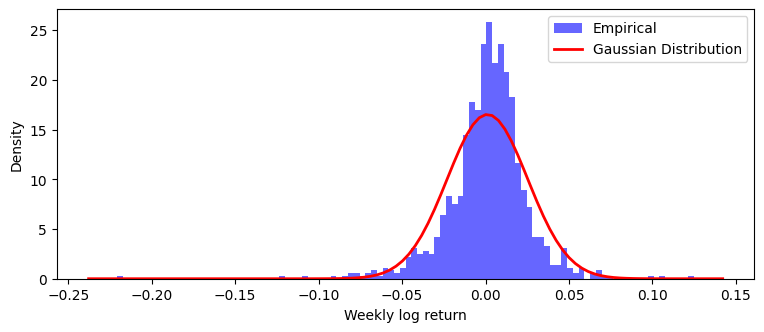

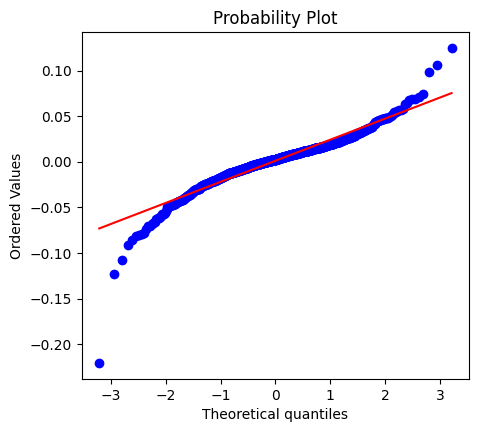

Excess Kurtosis Value: 9.48


In [8]:
#| label: fig-dist
#| fig-cap: "Weekly log returns compared with a Gaussian distribution."
#| fig-subcap:
#|   - "Empirical density against a fitted Gaussian."
#|   - "Normal quantile-quantile plot."
#| layout-ncol: 1
log_returns = spy_weekly_data["Log_Return"].dropna()

mu = log_returns.mean()
std = log_returns.std()

plt.figure(figsize=(9,3.5))
plt.hist(log_returns, bins=100, density=True, alpha=0.6, color='blue', label='Empirical')

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 100)

p = stats.norm.pdf(x, mu, std)

plt.plot(x, p, linewidth=2, color="red", label="Gaussian Distribution")
plt.xlabel("Weekly log return")
plt.ylabel("Density")
plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5,4.5))
stats.probplot(log_returns, dist="norm", plot=ax)
plt.show()

kurtosis_degeri = log_returns.kurtosis()
print(f"Excess Kurtosis Value: {kurtosis_degeri:.2f}")

### 4.4 Autocorrelation
These three ACF plots reveal a fundamental characteristic of financial markets. The first plot shows that raw log returns have almost zero autocorrelation, meaning the direction of price movements shows no linear dependence over time. However, the plots for absolute and squared returns display significant positive autocorrelation. This clearly demonstrates volatility clustering: large movements are followed by large movements. This persistent memory in volatility is what motivates a regime-switching description of the series.

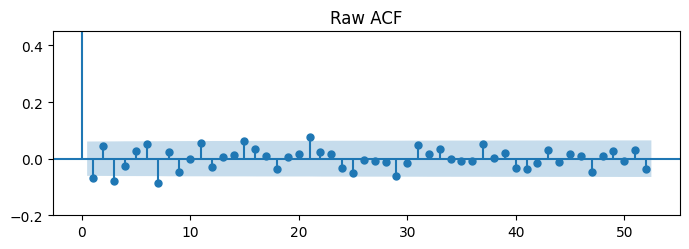

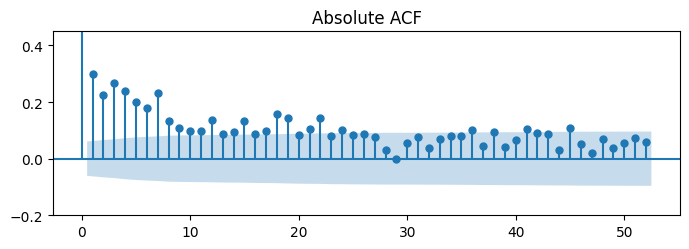

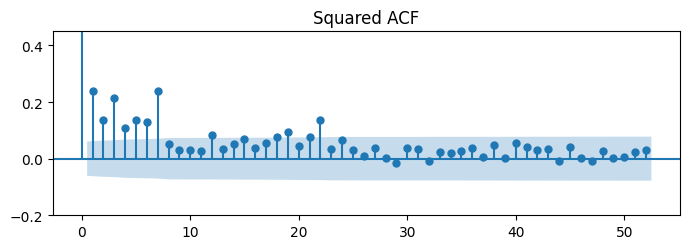

In [9]:
#| label: fig-acf
#| fig-cap: "Autocorrelation of weekly log returns, up to 52 lags."
#| fig-subcap:
#|   - "Raw returns."
#|   - "Absolute returns."
#|   - "Squared returns."
#| layout-ncol: 1
for series, title in [(log_returns, "Raw ACF"),
                      (log_returns.abs(), "Absolute ACF"),
                      (log_returns ** 2, "Squared ACF")]:
    fig, ax = plt.subplots(figsize=(7, 2.6))
    plot_acf(series, lags=52, ax=ax, title=title)
    ax.set_ylim(-0.2, 0.45)
    plt.tight_layout()
    plt.show()



### 4.5 Wealth index and Drawdown
This final section evaluates the long-term performance and downside risk of the asset. The Wealth Index illustrates the cumulative growth over time. Conversely, the Drawdown chart measures the percentage decline from historical peaks. The Maximum Drawdown is a critical risk metric, highlighting the worst-case capital loss an investor would have experienced during the observed period.

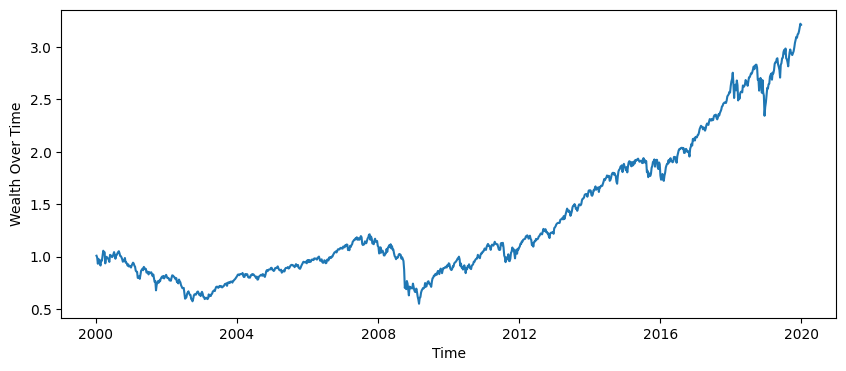

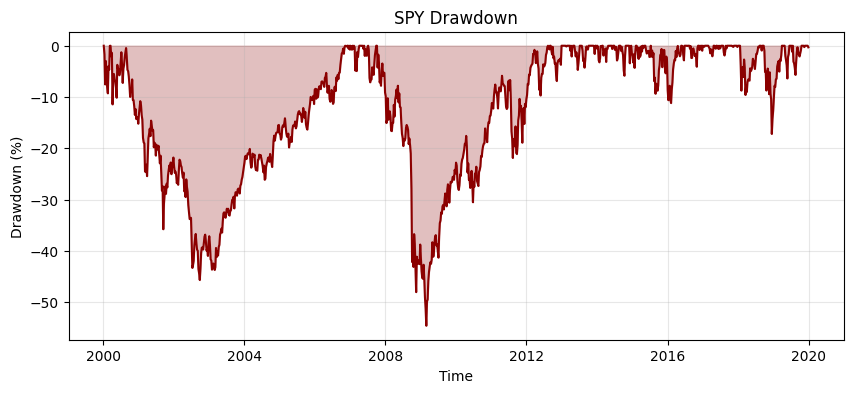

Peak wealth multiple: 3.22 on 2019-12-21
Maximum drawdown: -54.6% on 2009-02-28


In [10]:
#| label: fig-risk
#| fig-cap: "Cumulative performance and downside risk."
#| fig-subcap:
#|   - "Wealth index, one unit invested at the start."
#|   - "Drawdown from the running peak."
#| layout-ncol: 1
wealth_index = np.exp(log_returns.cumsum())

peak = wealth_index.cummax()          
drawdown = wealth_index / peak - 1
max_dd = drawdown.min()

plt.figure(figsize=(10,4))
plt.plot(wealth_index.index, wealth_index, label = "Wealth Index")
plt.ylabel("Wealth Over Time")
plt.xlabel("Time")
plt.show()


plt.figure(figsize=(10, 4))
plt.plot(drawdown.index, drawdown * 100, color="darkred")
plt.fill_between(
    drawdown.index,
    drawdown * 100,
    0,
    color="darkred",
    alpha=0.25
)

plt.title("SPY Drawdown")
plt.xlabel("Time")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.3)
plt.show()
print(f"Peak wealth multiple: {wealth_index.max():.2f} on {wealth_index.idxmax():%Y-%m-%d}")

print(f"Maximum drawdown: {max_dd:.1%} on {drawdown.idxmin():%Y-%m-%d}")

In [13]:
spy_weekly_data.to_csv("customized_spy_data_2000-2019.csv")

## 5. Discussion

Variance of logarithmic returns tends to change unlike the mean. As illustrated in @fig-series-2, return data oscillate around zero. @fig-vol demonstrates that the variance changes over time.

Time-varying variance naturally leads to excess kurtosis and fat tails in the empirical distribution, causing traditional risk models that assume a single Gaussian distribution to underestimate the probability of a market crash. Crucially, this fat tail is not an anomaly. A mixture of two normal distributions with distinct variances inherently produces fat tails. These findings are consistent with, but do not establish, a two-state variance structure.

The autocorrelation function of raw returns remains within the confidence bands (@fig-acf-1), indicating that the mean return does not need to transition between regimes. Conversely, absolute and squared returns suggest that volatility is highly regime dependent. Therefore, a framework utilizing a common mean paired with a switching variance emerges as the most parsimonious model that is consistent with observed stylized facts.

The drawdown analysis (@fig-risk-2) indicates why the high-volatility regime is important. Nearly all of the capital losses are in that period. However, these rolling variance metrics are inherently backward-looking; for instance, a 26-week rolling window often peaks only after the market has already bottomed. This inherent lag in traditional metrics leads to the ultimate question: can these high-risk market regimes be accurately detected in real-time?









## 6. Limitations

- The 26-week window is arbitrary; 13 and 52 weeks should be checked.
- No model was estimated. The findings are descriptive: the two-state
  structure is proposed, not demonstrated.
- Excess kurtosis is driven by a handful of extreme weeks.
- Results describe one asset over one period.



## 7. Next Step

Baselines against which any regime model must be judged: constant variance,
a rolling-volatility threshold, and an EWMA estimator, all fitted on the
training period only. Alongside these, the Gaussian log-likelihood will be
implemented and maximised directly, as groundwork for the Markov-switching
model.
